METODE               | WAKTU (s)  | IoU    | DICE   | ACC   

---> CITRA: Bimodal
Global (T=127)       | 0.00108    | 1.00   | 1.00   | 1.00  
Otsu                 | 0.00000    | 1.00   | 1.00   | 1.00  
Adaptif Mean         | 0.00211    | 0.31   | 0.48   | 0.64  
Adaptif Gaussian     | 0.00477    | 0.30   | 0.46   | 0.63  
Sobel                | 0.00111    | 0.04   | 0.07   | 0.74  
Prewitt              | 0.00250    | 0.24   | 0.38   | 0.47  
Canny                | 0.00235    | 0.02   | 0.04   | 0.75  
Watershed            | 0.00940    | 0.00   | 0.00   | 0.02  
Connected Comp       | 0.00000    | 1.00   | 1.00   | 1.00  
Region Growing       | 0.00000    | 0.66   | 0.80   | 0.91  


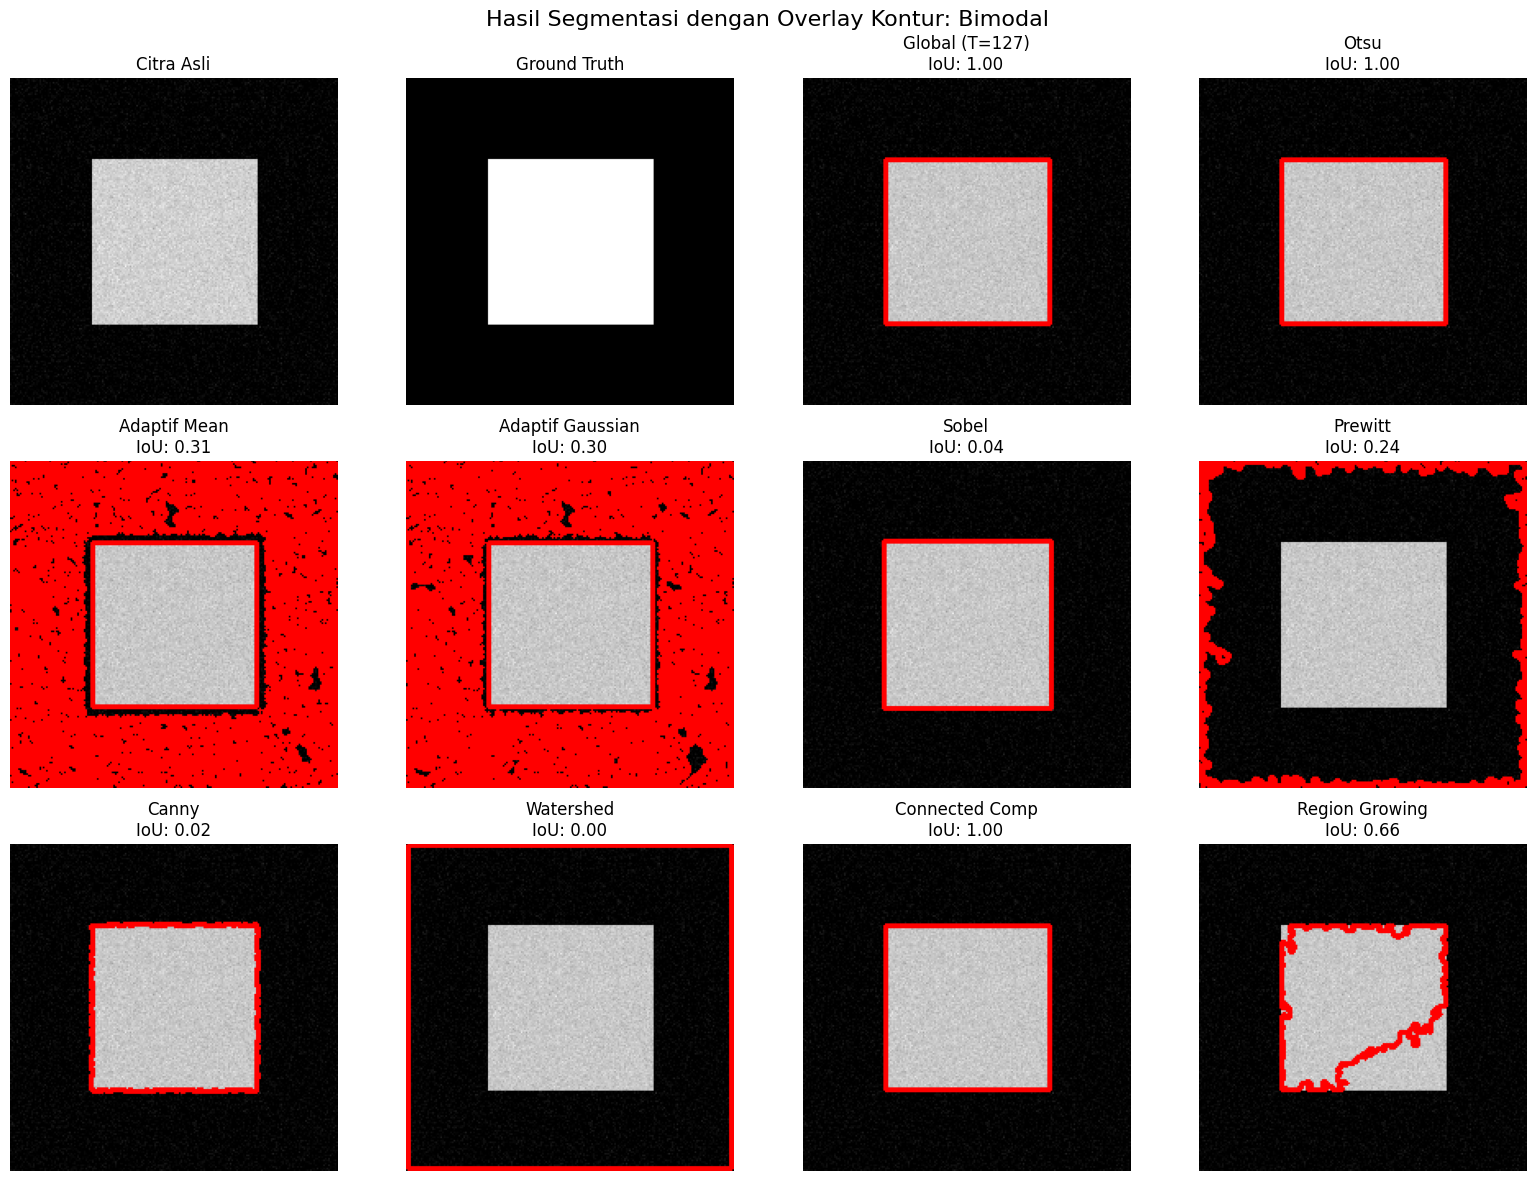


---> CITRA: Iluminasi_Tidak_Merata
Global (T=127)       | 0.00000    | 0.26   | 0.42   | 0.61  
Otsu                 | 0.00000    | 0.28   | 0.44   | 0.64  
Adaptif Mean         | 0.00000    | 0.15   | 0.26   | 0.20  
Adaptif Gaussian     | 0.00000    | 0.15   | 0.26   | 0.18  
Sobel                | 0.00000    | 0.06   | 0.12   | 0.86  
Prewitt              | 0.00695    | 0.00   | 0.01   | 0.02  
Canny                | 0.00000    | 0.03   | 0.06   | 0.86  
Watershed            | 0.00068    | 0.00   | 0.00   | 0.48  
Connected Comp       | 0.00000    | 0.28   | 0.44   | 0.64  
Region Growing       | 0.00000    | 0.00   | 0.00   | 0.00  


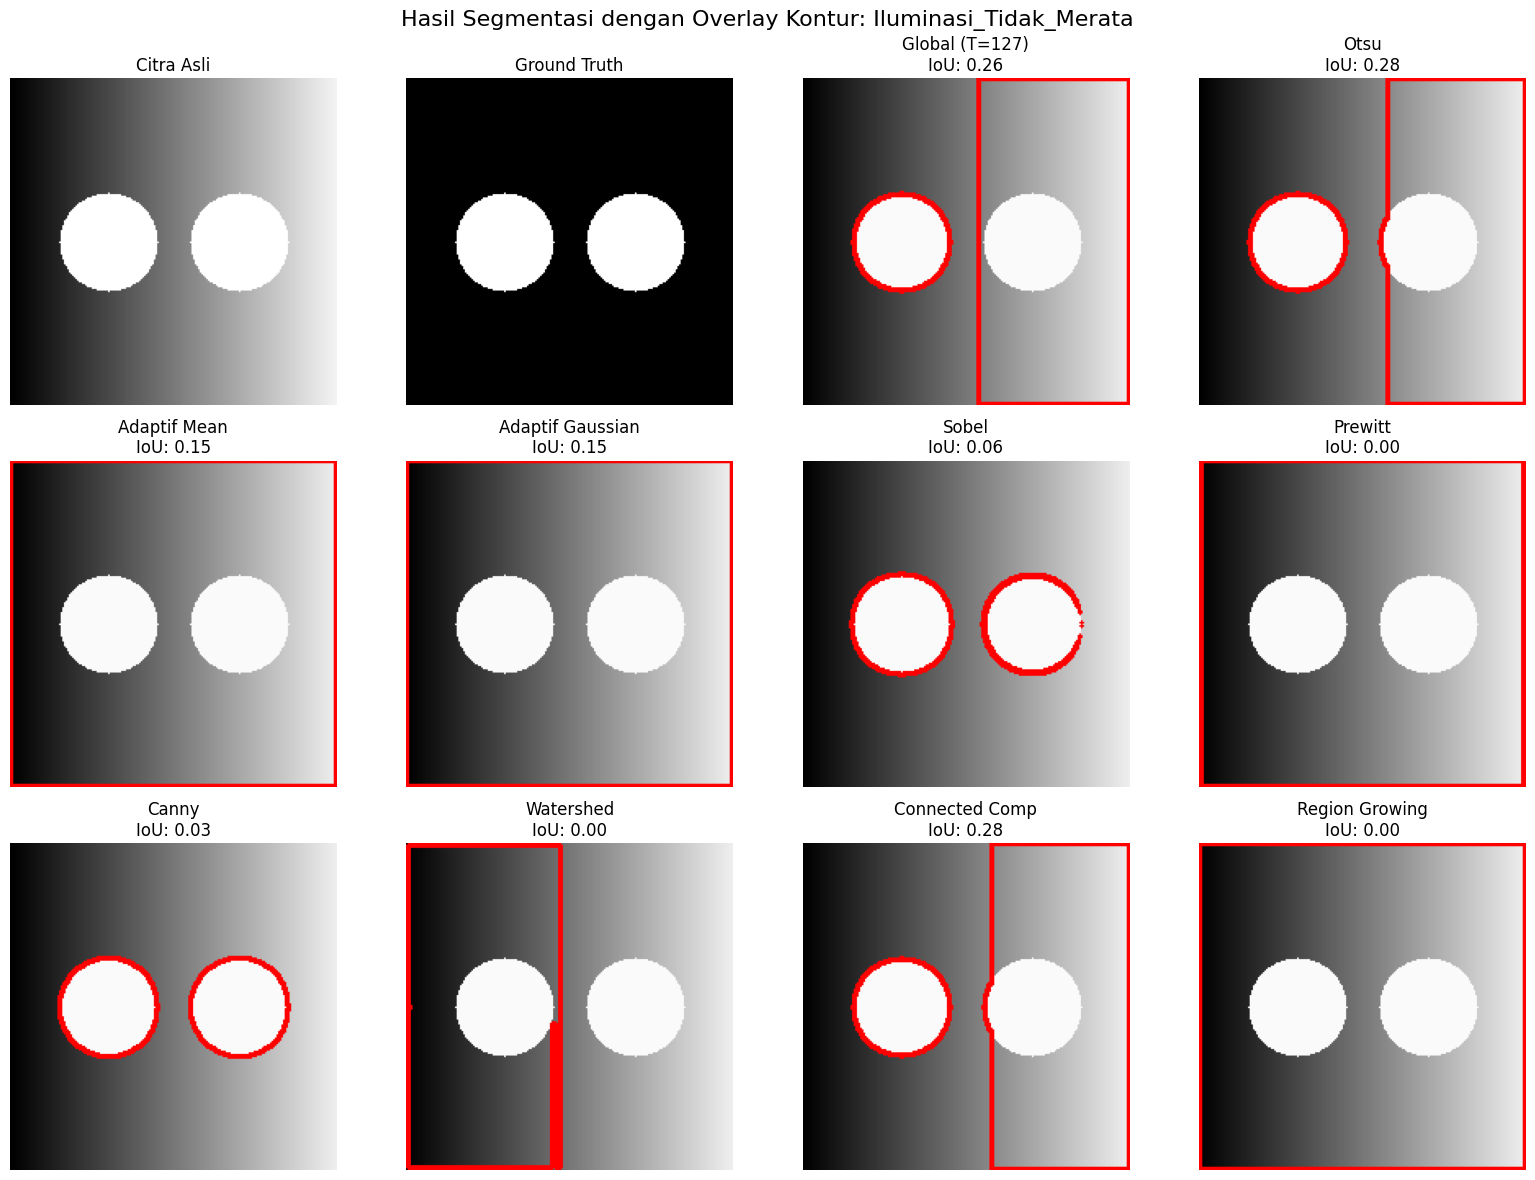


---> CITRA: Tumpang_Tindih
Global (T=127)       | 0.00000    | 1.00   | 1.00   | 1.00  
Otsu                 | 0.00000    | 1.00   | 1.00   | 1.00  
Adaptif Mean         | 0.00000    | 0.32   | 0.48   | 0.64  
Adaptif Gaussian     | 0.00039    | 0.30   | 0.46   | 0.63  
Sobel                | 0.00000    | 0.05   | 0.09   | 0.73  
Prewitt              | 0.00270    | 0.24   | 0.39   | 0.45  
Canny                | 0.00000    | 0.10   | 0.18   | 0.75  
Watershed            | 0.00000    | 0.00   | 0.00   | 0.02  
Connected Comp       | 0.00000    | 1.00   | 1.00   | 1.00  
Region Growing       | 0.00000    | 0.01   | 0.01   | 0.73  


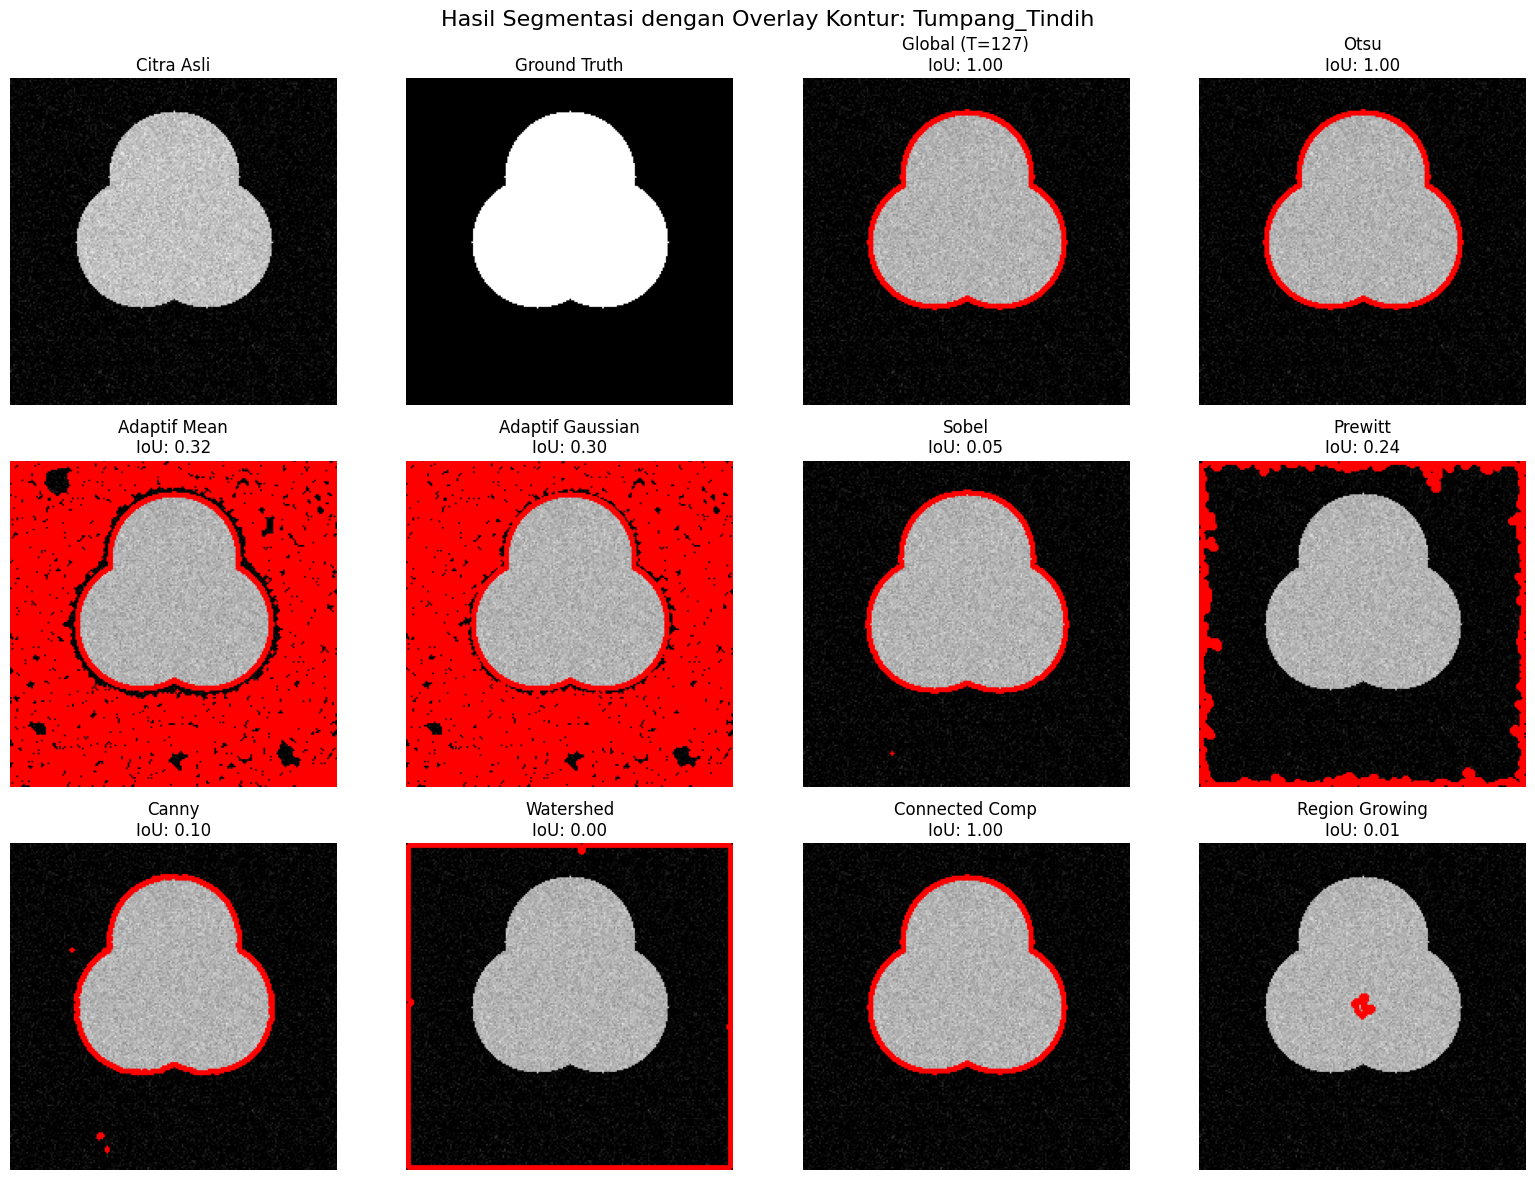


Proses Selesai. Gunakan data di atas untuk menyusun laporan Anda.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from skimage import measure

# ==========================================
# 1. PERSIAPAN CITRA & GROUND TRUTH (SINTETIS)
# ==========================================
def create_synthetic_images():
    images = {}
    
    # 1. Citra Bimodal (Kontras Tinggi)
    img_bi = np.zeros((200, 200), dtype=np.uint8)
    img_bi = cv2.rectangle(img_bi, (50, 50), (150, 150), 200, -1)
    gt_bi = (img_bi > 0).astype(np.uint8)
    # PERBAIKAN: Cara menambahkan noise yang benar agar tidak underflow
    noise = np.random.normal(0, 10, img_bi.shape)
    img_bi = np.clip(img_bi.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    images['Bimodal'] = (img_bi, gt_bi)
    
    # 2. Citra Iluminasi Tidak Merata
    img_un = np.zeros((200, 200), dtype=np.float32)
    # Buat background gradient
    for i in range(200):
        img_un[:, i] = i * 1.2
    # Tambahkan objek
    cv2.circle(img_un, (60, 100), 30, 250, -1)
    cv2.circle(img_un, (140, 100), 30, 250, -1)
    img_un = np.clip(img_un, 0, 255).astype(np.uint8)
    
    gt_un = np.zeros((200, 200), dtype=np.uint8)
    cv2.circle(gt_un, (60, 100), 30, 1, -1)
    cv2.circle(gt_un, (140, 100), 30, 1, -1)
    images['Iluminasi_Tidak_Merata'] = (img_un, gt_un)
    
    # 3. Citra Objek Tumpang Tindih (Sel/Koin)
    img_ov = np.zeros((200, 200), dtype=np.uint8)
    cv2.circle(img_ov, (80, 100), 40, 180, -1)
    cv2.circle(img_ov, (120, 100), 40, 180, -1)
    cv2.circle(img_ov, (100, 60), 40, 180, -1)
    # PERBAIKAN: Sama seperti bimodal
    noise2 = np.random.normal(0, 15, img_ov.shape)
    img_ov = np.clip(img_ov.astype(np.float32) + noise2, 0, 255).astype(np.uint8)
    
    gt_ov = np.zeros((200, 200), dtype=np.uint8)
    cv2.circle(gt_ov, (80, 100), 40, 1, -1)
    cv2.circle(gt_ov, (120, 100), 40, 1, -1)
    cv2.circle(gt_ov, (100, 60), 40, 1, -1)
    images['Tumpang_Tindih'] = (img_ov, gt_ov)
    
    return images

# ==========================================
# FUNGSI EVALUASI METRIK
# ==========================================
def calculate_metrics(pred, gt):
    pred = (pred > 0).astype(np.uint8)
    gt = (gt > 0).astype(np.uint8)
    
    TP = np.sum((pred == 1) & (gt == 1))
    TN = np.sum((pred == 0) & (gt == 0))
    FP = np.sum((pred == 1) & (gt == 0))
    FN = np.sum((pred == 0) & (gt == 1))
    
    iou = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0
    dice = (2 * TP) / ((2 * TP) + FP + FN) if ((2 * TP) + FP + FN) > 0 else 0
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    
    return {"IoU": iou, "Dice": dice, "Acc": accuracy, "Prec": precision, "Rec": recall}

# ==========================================
# 2. METODE AMBANG BATAS (THRESHOLDING)
# ==========================================
def apply_thresholding(img):
    results = {}
    
    # Global Manual
    start = time.time()
    _, th_global = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    results['Global (T=127)'] = (th_global, time.time() - start)
    
    # Otsu
    start = time.time()
    _, th_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    results['Otsu'] = (th_otsu, time.time() - start)
    
    # Adaptive Mean & Gaussian
    start = time.time()
    th_adapt_mean = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)
    results['Adaptif Mean'] = (th_adapt_mean, time.time() - start)
    
    start = time.time()
    th_adapt_gauss = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
    results['Adaptif Gaussian'] = (th_adapt_gauss, time.time() - start)
    
    return results

# ==========================================
# 3. DETEKSI TEPI (EDGE DETECTION)
# ==========================================
def apply_edge_detection(img):
    results = {}
    
    # Sobel
    start = time.time()
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel_mag = np.sqrt(sobelx**2 + sobely**2)
    sobel_mag = np.uint8(255 * sobel_mag / np.max(sobel_mag))
    _, sobel_bin = cv2.threshold(sobel_mag, 50, 255, cv2.THRESH_BINARY) # Binarization for metrik
    results['Sobel'] = (sobel_bin, time.time() - start)
    
    # Prewitt
    start = time.time()
    kernelx = np.array([[1,1,1],[0,0,0],[-1,-1,-1]])
    kernely = np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
    prewittx = cv2.filter2D(img, -1, kernelx)
    prewitty = cv2.filter2D(img, -1, kernely)
    prewitt_mag = np.sqrt(np.square(prewittx) + np.square(prewitty))
    prewitt_mag = np.uint8(255 * prewitt_mag / np.max(prewitt_mag))
    _, prewitt_bin = cv2.threshold(prewitt_mag, 50, 255, cv2.THRESH_BINARY)
    results['Prewitt'] = (prewitt_bin, time.time() - start)
    
    # Canny
    start = time.time()
    canny = cv2.Canny(img, 100, 200)
    results['Canny'] = (canny, time.time() - start)
    
    return results

# ==========================================
# 4. SEGMENTASI BERBASIS WILAYAH
# ==========================================
def apply_region_based(img):
    results = {}
    
    # Watershed (Marker-based)
    start = time.time()
    _, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = np.ones((3,3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    sure_bg = cv2.dilate(opening, kernel, iterations=3)
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist_transform, 0.5*dist_transform.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0
    img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    cv2.watershed(img_color, markers)
    ws_result = np.zeros_like(img)
    ws_result[markers > 1] = 255 # Extract regions
    results['Watershed'] = (ws_result, time.time() - start)
    
    # Connected Components (Dari hasil Otsu)
    start = time.time()
    _, otsu_bin = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    num_labels, labels = cv2.connectedComponents(otsu_bin)
    cc_result = (labels > 0).astype(np.uint8) * 255
    results['Connected Comp'] = (cc_result, time.time() - start)
    
    # Region Growing (FloodFill)
    start = time.time()
    h, w = img.shape
    mask = np.zeros((h+2, w+2), np.uint8)
    rg_result = img.copy()
    # Asumsi seed point di tengah (untuk menyederhanakan)
    seed_pt = (w//2, h//2) 
    cv2.floodFill(rg_result, mask, seed_pt, 255, 10, 10)
    _, rg_bin = cv2.threshold(rg_result, 254, 255, cv2.THRESH_BINARY)
    results['Region Growing'] = (rg_bin, time.time() - start)
    
    return results

# ==========================================
# 5. EKSEKUSI UTAMA & EVALUASI
# ==========================================
images = create_synthetic_images()

print("="*60)
print(f"{'METODE':<20} | {'WAKTU (s)':<10} | {'IoU':<6} | {'DICE':<6} | {'ACC':<6}")
print("="*60)

for img_name, (img, gt) in images.items():
    print(f"\n---> CITRA: {img_name}")
    
    all_results = {}
    all_results.update(apply_thresholding(img))
    all_results.update(apply_edge_detection(img))
    all_results.update(apply_region_based(img))
    
    # Visualisasi Setup (3 Baris, 4 Kolom)
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    fig.suptitle(f'Hasil Segmentasi dengan Overlay Kontur: {img_name}', fontsize=16)
    axes = axes.ravel()
    
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Citra Asli')
    axes[0].axis('off')
    
    axes[1].imshow(gt, cmap='gray')
    axes[1].set_title('Ground Truth')
    axes[1].axis('off')
    
    idx = 2
    for method_name, (pred_img, exec_time) in all_results.items():
        metrics = calculate_metrics(pred_img, gt)
        print(f"{method_name:<20} | {exec_time:<10.5f} | {metrics['IoU']:<6.2f} | {metrics['Dice']:<6.2f} | {metrics['Acc']:<6.2f}")
        
        if idx < len(axes):
            # 1. Pastikan pred_img adalah gambar biner (0 atau 255) tipe uint8
            pred_img_binary = (pred_img > 0).astype(np.uint8) * 255
            
            # 2. Buat citra berwarna (RGB) dari citra asli sebagai background agar kontur terlihat merah
            img_color_overlay = cv2.cvtColor(img.copy(), cv2.COLOR_GRAY2RGB)
            
            # 3. Cari kontur dari hasil segmentasi prediksi
            contours, _ = cv2.findContours(pred_img_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            # 4. Gambar kontur pada citra background (warna merah, ketebalan 2 pixel agar jelas)
            cv2.drawContours(img_color_overlay, contours, -1, (255, 0, 0), 2)
            
            # Tampilkan hasilnya
            axes[idx].imshow(img_color_overlay)
            axes[idx].set_title(f"{method_name}\nIoU: {metrics['IoU']:.2f}")
            axes[idx].axis('off')
            idx += 1
            
    # Sembunyikan subplot sisa (jika ada yang kosong di grid akhir)
    for i in range(idx, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

print("\nProses Selesai. Gunakan data di atas untuk menyusun laporan Anda.")